In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split, Dataset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

CONFIG = {
    "seed": 42,
    "image_size": 224,          # Standardized for ResNet-50
    "batch_size": 32,           # Increased since 224x224 uses less VRAM
    "accum_steps": 1,           
    "num_workers": 2,
    "num_epochs": 100,          
    "learning_rate": 1e-4,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

 
raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_val = datasets.ImageFolder(VAL_DIR)
full_dataset = ConcatDataset([raw_train, raw_val])

CLASS_TO_IDX = raw_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# Calculate 70/15/15 splits
total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset, 
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

 
class TransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = TransformWrapper(train_subset, transform=train_transforms)
val_dataset = TransformWrapper(val_subset, transform=val_test_transforms)
test_dataset = TransformWrapper(test_subset, transform=val_test_transforms)

print(f"Total images: {total_len}")
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

Total images: 5000
Train images: 3500 | Val images: 750 | Test images: 750


In [4]:
def build_resnet_model(num_classes=2):
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

model = build_resnet_model(num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-50 ready on {DEVICE}. Trainable parameters: {num_trainable:,}")

ResNet-50 ready on cuda. Trainable parameters: 23,512,130


Epoch 001/100 | train_loss=0.5136 train_acc=0.7463 | val_loss=0.5047 val_acc=0.7640 | 35.8s [*Saved Best Checkpoint]
Epoch 002/100 | train_loss=0.4301 train_acc=0.7949 | val_loss=0.8834 val_acc=0.5933 | 24.9s
Epoch 003/100 | train_loss=0.4111 train_acc=0.8109 | val_loss=0.3756 val_acc=0.8360 | 25.2s [*Saved Best Checkpoint]
Epoch 004/100 | train_loss=0.3812 train_acc=0.8334 | val_loss=0.3863 val_acc=0.8267 | 24.9s
Epoch 005/100 | train_loss=0.3552 train_acc=0.8446 | val_loss=0.3825 val_acc=0.8373 | 25.1s [*Saved Best Checkpoint]
Epoch 006/100 | train_loss=0.3057 train_acc=0.8729 | val_loss=0.3751 val_acc=0.8360 | 25.5s [*Saved Best Checkpoint]
Epoch 007/100 | train_loss=0.3006 train_acc=0.8709 | val_loss=0.4024 val_acc=0.8107 | 25.6s
Epoch 008/100 | train_loss=0.2943 train_acc=0.8757 | val_loss=0.4248 val_acc=0.8000 | 25.6s
Epoch 009/100 | train_loss=0.2681 train_acc=0.8871 | val_loss=0.3694 val_acc=0.8387 | 25.7s [*Saved Best Checkpoint]
Epoch 010/100 | train_loss=0.2547 train_acc=0.8

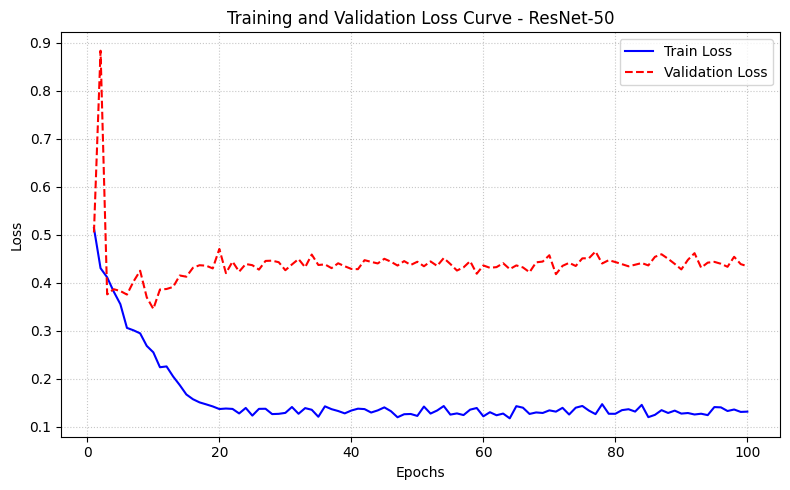

In [5]:
scaler = torch.amp.GradScaler('cuda')

def run_epoch(model, loader, criterion, optimizer=None, accum_steps=1):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    if is_training:
        optimizer.zero_grad()

    torch.set_grad_enabled(is_training)
    for step, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_training:
                loss = loss / accum_steps

        if is_training:
            scaler.scale(loss).backward()
            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    torch.set_grad_enabled(True)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

best_val_acc = 0.0
best_val_loss = float('inf')
CHECKPOINT_PATH = "/kaggle/working/resnet50_best_checkpoint.pth"

history_train_loss = []
history_val_loss = []

for epoch in range(1, CONFIG["num_epochs"] + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, accum_steps=CONFIG["accum_steps"])
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)
    
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)

    saved = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True
    elif val_loss < best_val_loss:
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True

    if val_loss < best_val_loss:
        best_val_loss = val_loss

    elapsed = time.time() - start
    chkpt_msg = " [*Saved Best Checkpoint]" if saved else ""
    print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} "
          f"| train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
          f"| {elapsed:.1f}s{chkpt_msg}")

model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f"\nTraining completed. Loaded best checkpoint for evaluation.")

# Plot Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, CONFIG["num_epochs"] + 1), history_train_loss, label='Train Loss', color='blue')
plt.plot(range(1, CONFIG["num_epochs"] + 1), history_val_loss, label='Validation Loss', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve - ResNet-50')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

          ai       0.84      0.81      0.82       370
      nature       0.82      0.85      0.84       380

    accuracy                           0.83       750
   macro avg       0.83      0.83      0.83       750
weighted avg       0.83      0.83      0.83       750



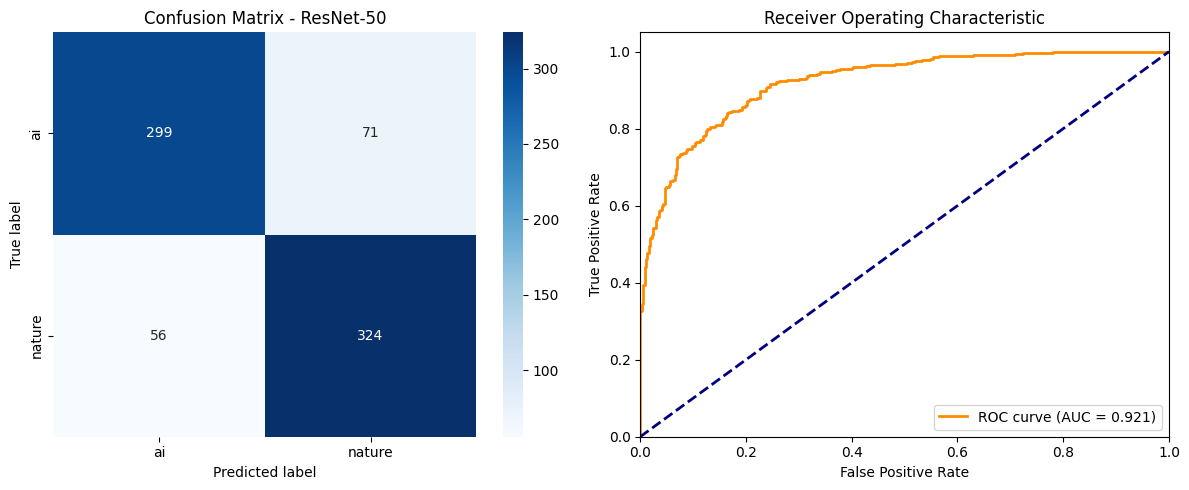

In [6]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().tolist() 
        preds = outputs.argmax(dim=1).cpu().tolist()
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print("===== Classification Report (Test Set) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[0])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix - ResNet-50")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [7]:
output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
pos_lbl = CLASS_TO_IDX.get("ai", 0) 
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_wukong",
    "model": "resnet50",
    "num_epochs": CONFIG["num_epochs"],
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])


display(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "resnet50_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "resnet50_best_model.pth")
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

,dataset,model,num_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_wukong,resnet50,100,3500,750,0.8307,0.8423,0.8081,0.8248,0.9212



===== Download Links =====


/kaggle/working/results/resnet50_test_results.csv

/kaggle/working/results/resnet50_best_model.pth